# Getting Started: Market Research
This Jupyter notebook is a quick demonstration on how to get started on the market research section.

## 1) Download Data
Please download the train and test data and place it within the ./research/data path. If you've placed it in the correct place, you should see the following cell work:

In [2]:
import pandas as pd

train_data = pd.read_csv('./data/train.csv')
test_data = pd.read_csv('./data/test.csv')

print(train_data.head())
print(test_data.head())

   time         A         B         C         D         E         F         G  \
0     0  0.207366 -0.159951 -0.634176 -0.580962 -0.266505  0.060173 -0.475257   
1     1  0.188828 -0.265508  0.042143 -0.550442 -0.132319 -0.185219  0.028295   
2     2 -0.144261 -0.577142 -0.214634 -0.747391 -0.184255 -0.464831 -0.085181   
3     3  0.208982 -0.310449  0.513708 -0.562868  0.742308 -0.305487  0.762246   
4     4  0.093320 -0.358156  0.173188 -0.687296 -0.161461 -0.116062 -0.245748   

          H         I         J         K         L         M         N  \
0 -1.486516 -0.332594 -0.671466 -0.226149 -0.187624 -0.780237 -0.785965   
1  0.093210 -0.518139 -0.251917 -0.347845 -0.359069 -0.161254  0.020401   
2  0.700449 -0.603438  0.197773 -0.566696 -0.580799  0.202726  0.135261   
3  1.363020 -0.384575  0.525556 -0.348514 -0.428099  0.548993  0.471031   
4  0.863372 -0.655588 -0.263358 -0.557428 -0.481214  0.083602  0.003087   

         Y1        Y2  
0 -0.935902 -0.310081  
1 -0.089707 -0

## 2) Investigate the Dataset
In the datasets, you're given columns of time and A through N, each of which represent some sort of real-life market quantity. In the train dataset, you're also given Y1 and Y2, real-life market quantities you'd like to predict in terms of time and A through N. You're not given Y1 and Y2 in the test set, because this is what you're being asked to predict.

Let's do some exploration of the relationships of A - N and Y1. In particular, let's look at the relationship between C and Y1:

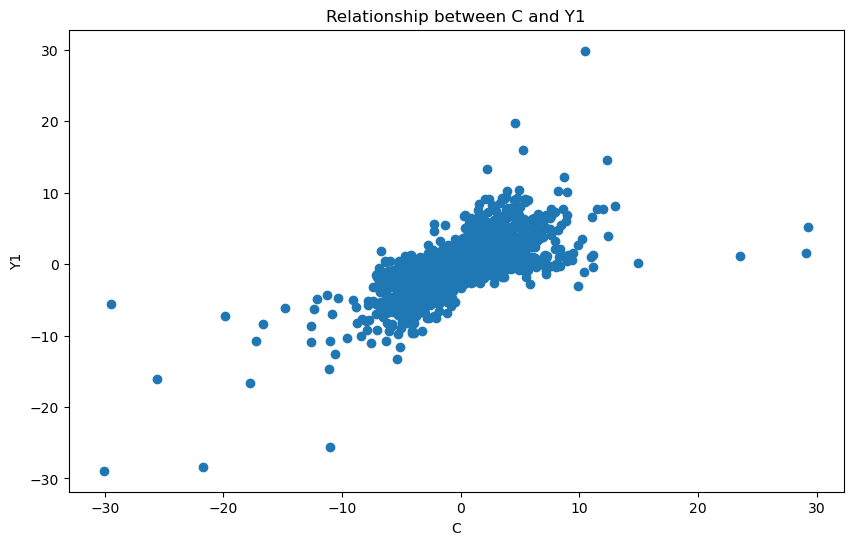

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_data['C'], train_data['Y1'])
plt.xlabel('C')
plt.ylabel('Y1')
plt.title('Relationship between C and Y1')
plt.show()

In [4]:
# Calculate correlation between C and Y1
correlation = train_data['C'].corr(train_data['Y1'])
print(f"Correlation between C and Y1: {correlation:.4f}")

Correlation between C and Y1: 0.7038


Clearly there's a strong relationship between C and Y1. You should definitely use C to predict Y1!

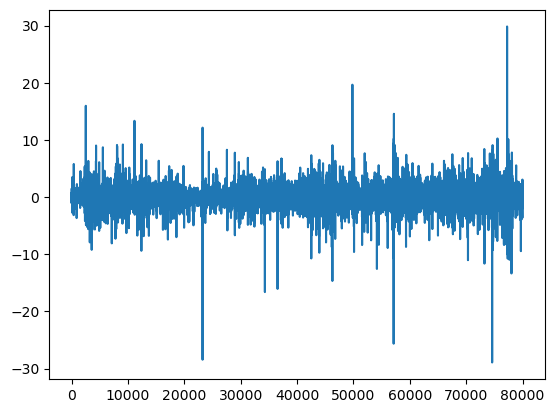

In [16]:
plt.plot(train_data["Y1"])

In [20]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
Y1 = train_data[["Y1"]]
Y2 = train_data[["Y2"]]
X = train_data.drop(columns=["Y1", "Y2", "time"])
X2 = train_data.drop(columns=["Y2", "time"])
tscv = TimeSeriesSplit(n_splits=5)

In [23]:
param_grid = {
    'n_estimators': [100, 200, 500, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7, 8],
}

xgb_reg = xgb.XGBRegressor(random_state=1)

grid_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_grid,
    n_iter=100,
    scoring='r2',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=1
)
grid_search.fit(X, Y1)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [24]:
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    Y1_train, Y1_test = Y1.iloc[train_idx], Y1.iloc[test_idx]
    Y2_train, Y2_test = Y2.iloc[train_idx], Y2.iloc[test_idx]
    xgb_model_1 = xgb.XGBRegressor(
        **grid_search.best_params_
    )
    xgb_model_2 = xgb.XGBRegressor(
        **grid_search.best_params_
    )
    xgb_model_1.fit(X_train, Y1_train)
    xgb_model_2.fit(X_train, Y2_train)

    Y1_pred = xgb_model_1.predict(X_test)
    Y2_pred = xgb_model_2.predict(X_test)

    Y1_r2 = r2_score(Y1_test, Y1_pred)
    Y2_r2 = r2_score(Y2_test, Y2_pred)

    print(f"{Y1_r2 = }")
    print(f"{Y2_r2 = }")

Y1_r2 = 0.728568434715271
Y2_r2 = 0.6546988487243652
Y1_r2 = 0.6838037967681885
Y2_r2 = 0.600961446762085
Y1_r2 = 0.7622405886650085
Y2_r2 = 0.6892527937889099
Y1_r2 = 0.7594778537750244
Y2_r2 = 0.693221926689148
Y1_r2 = 0.6991150975227356
Y2_r2 = 0.5088962316513062


In [ ]:
xgb_model_1_tuned = xgb.XGBRegressor(**grid_search.best_params_)
xgb_model_1.fit(X, Y1)
xgb_model_1.predict()

## 3) Submit Predictions
In order to submit predictions, we need to make a CSV file with three columns: id, Y1, and Y2. In the below example, we let our predictions of Y1 and Y2 be the means of Y1 and Y2 in the train set.

In [30]:
# save preds to csv
preds.to_csv('preds.csv', index=False)